# DataScienceChallenge

# Projet 1/10 : Nettoyage & Exploration de Données avec Python
Objectif : Maîtriser la manipulation et la visualisation de données brutes


# Phase 0 : Description du jeu de données

L'ensemble de données Titanic est un jeu de données classique et largement utilisé en data science. Il contient des informations détaillées sur les passagers du navire Titanic, qui a fait naufrage en 1912. Les variables disponibles incluent l'âge, le sexe, la classe de billet (Pclass), le prix du billet (Fare), le nombre de frères/époux à bord (SibSp), le nombre de parents/enfants à bord (Parch), le port d'embarquement (Embarked), ainsi que d'autres attributs comme le nom, le numéro de cabine et le numéro de ticket.

Dans ce projet, nous nous concentrons uniquement sur l’analyse exploratoire des données (EDA). Notre objectif est de découvrir des informations clés sur la répartition des passagers, d’identifier des tendances ou des biais (par exemple, les différences de survie selon le sexe ou la classe sociale), et de comprendre la structure des données (valeurs manquantes, distributions, relations entre variables). Cette analyse exploratoire nous permettra de tirer des enseignements sur le profil des passagers et les facteurs ayant pu influencer leur sort, sans chercher à construire un modèle prédictif

# Phase 1 : visualisation des donnees brutes

## Importation des librairies et chargement du fichier

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Pour que les graphiques s'affichent dans le notebook
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

In [3]:
# Charger les données
df = pd.read_csv("train.csv")


## Lecture du fichier

In [4]:
print("Exemple de 20 passagers :")
df.sample(20)

Exemple de 20 passagers :


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
409,410,0,3,"Lefebre, Miss. Ida",female,NaN,3,1,4133,25.4667,NaN,S
64,65,0,1,"Stewart, Mr. Albert A",male,NaN,0,0,PC 17605,27.7208,NaN,C
857,858,1,1,"Daly, Mr. Peter Denis",male,51.0,0,0,113055,26.5500,E17,S
731,732,0,3,"Hassan, Mr. Houssein G N",male,11.0,0,0,2699,18.7875,NaN,C
289,290,1,3,"Connolly, Miss. Kate",female,22.0,0,0,370373,7.7500,NaN,Q
345,346,1,2,"Brown, Miss. Amelia ""Mildred""",female,24.0,0,0,248733,13.0000,F33,S
678,679,0,3,"Goodwin, Mrs. Frederick (Augusta Tyler)",female,43.0,1,6,CA 2144,46.9000,NaN,S
558,559,1,1,"Taussig, Mrs. Emil (Tillie Mandelbaum)",female,39.0,1,1,110413,79.6500,E67,S
147,148,0,3,"Ford, Miss. Robina Maggie ""Ruby""",female,9.0,2,2,W./C. 6608,34.3750,NaN,S
291,292,1,1,"Bishop, Mrs. Dickinson H (Helen Walton)",female,19.0,1,0,11967,91.0792,B49,C


## Observation

Nous observons différentes caractéristiques telles que l'âge, le sexe, la classe, le prix du billet et si le passager a survécu.
Cela nous permet d'avoir un aperçu rapide du type de données avec lesquelles nous travaillons, y compris des problèmes potentiels comme les valeurs manquantes.
Il semble que nous ayons des colonnes redondantes.
Quelques valeurs NaN sont clairement visibles dans le deck et son âge.

# Phase 2 : Recherche d'information sur les données

In [5]:
# Informations générales (types de données, valeurs manquantes)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
# Informations sur les types de données
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

Interprétation :

891 passagers au total.

177 valeurs manquantes pour Age (20%).

687 valeurs manquantes pour Cabin (77%).

2 valeurs manquantes pour Embarked.

# Phase 3 : Statistiques de base

Nous allons maintenant résumer les colonnes numériques et catégorielles afin de mieux comprendre les tendances centrales, la variabilité et les éventuelles données manquantes.

Lors de l'exploration de données numériques :

Moyenne vs Médiane : Comparez la moyenne et la médiane. Si la moyenne est nettement supérieure ou inférieure à la médiane, cela indique une asymétrie dans les données, possiblement due à des valeurs aberrantes.
Valeurs minimales et maximales : Examinez les valeurs minimales et maximales pour détecter les valeurs aberrantes extrêmes ou les erreurs potentielles de saisie de données.
Écart type : Un écart type élevé indique que les points de données sont répartis sur une large plage de valeurs, tandis qu'un écart type faible suggère que les points de données sont regroupés autour de la moyenne.
Lors de l'exploration de données catégorielles :

Nombre de catégories uniques : vérifiez le nombre de catégories uniques. Par exemple, la colonne « sexe » comporte deux catégories uniques (« homme » et « femme »), tandis que la colonne « pclass » en comporte trois.
Mode : Le mode (catégorie la plus fréquente) nous aide à comprendre quelle catégorie domine l’ensemble de données. Par exemple, si la plupart des passagers sont des hommes ou appartiennent à une classe sociale particulière, cela orientera notre analyse.
Répartition des fréquences : Analysez la fréquence de chaque catégorie afin d’identifier d’éventuels déséquilibres. Par exemple, y a-t-il plus de passagers d’une classe ou d’un point d’embarquement particulier ? Des catégories déséquilibrées peuvent biaiser le modèle si elles ne sont pas correctement prises en compte.
Catégories manquantes ou rares : si une catégorie est très peu fréquente, cela peut indiquer la présence de bruit ou d’anomalies dans les données.

In [7]:
# Statistiques descriptives
df.describe().T

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


Interprétation :

Survie moyenne : 38,4% (0,3838).

Âge moyen : environ 29,7 ans, avec des valeurs extrêmes (0,42 à 80 ans).

Tarif moyen : 32,20, mais écart-type élevé (49,69) indiquant une forte dispersion.

Médiane du tarif (14,45) bien inférieure à la moyenne → asymétrie droite due à quelques tarifs très élevés (max 512).

In [8]:
df.describe(include='object')

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Dooley, Mr. Patrick",male,347082,G6,S
freq,1,577,7,4,644


Sexe : 577 hommes, 314 femmes.

Embarked : 644 départs de Southampton, 168 de Cherbourg, 77 de Queenstown.

## Interpretation des resultats

Âge : L’âge moyen est d’environ 30 ans, mais on observe des valeurs manquantes et quelques valeurs extrêmes (min. = 0,42, max. = 80). La moyenne et la médiane sont proches, ce qui suggère une distribution assez symétrique pour la plupart des passagers.
Tarif : Le tarif présente une large fourchette, de 0 à 512. Cette grande fourchette et la différence entre la moyenne et la médiane (moyenne > médiane) suggèrent la présence de valeurs aberrantes, certains passagers payant des tarifs beaucoup plus élevés.
Parch et SibSp : La plupart des passagers avaient peu ou pas de proches à bord, avec une médiane de 0 pour les deux colonnes.
Classe P : La plupart des passagers sont en 3ème classe (mode : 3).


Une part importante des passagers n'a pas survécu (taux de survie inférieur à 50 %).
Ces données montrent une prédominance d'hommes par rapport aux femmes, les hommes adultes étant les plus nombreux (par rapport aux garçons).
Southampton (S) est le point d'embarquement le plus fréquent (parmi les trois options).
Bien que ce résumé fournisse des informations utiles, il ne révèle pas la répartition de toutes les catégories, notamment les catégories rares. Par exemple, il n'indique que la catégorie la plus fréquente (le mode) et sa fréquence, sans montrer la répartition des autres catégories, en particulier celles qui apparaissent très rarement.

## Analyse de valeurs rares 

Pour détecter les catégories rares dans l'ensemble de données, nous examinerons la distribution de fréquence de chaque colonne catégorielle. Cela nous permettra de déterminer s'il existe des catégories très peu fréquentes, qui pourraient correspondre à du bruit ou à des anomalies.

Il est important d'identifier les catégories rares car elles peuvent introduire un biais ou affecter les performances du modèle si elles ne sont pas traitées correctement.

In [9]:
# Frequency distribution for categorical columns
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f"Value counts for {col}:")
    print(df[col].value_counts())
    print("\n")

Value counts for Name:
Name
Dooley, Mr. Patrick                                    1
Braund, Mr. Owen Harris                                1
Cumings, Mrs. John Bradley (Florence Briggs Thayer)    1
Heikkinen, Miss. Laina                                 1
Futrelle, Mrs. Jacques Heath (Lily May Peel)           1
                                                      ..
Hewlett, Mrs. (Mary D Kingcome)                        1
Vestrom, Miss. Hulda Amanda Adolfina                   1
Andersson, Mr. Anders Johan                            1
Saundercock, Mr. William Henry                         1
Bonnell, Miss. Elizabeth                               1
Name: count, Length: 891, dtype: int64


Value counts for Sex:
Sex
male      577
female    314
Name: count, dtype: int64


Value counts for Ticket:
Ticket
347082              7
1601                7
CA. 2343            7
3101295             6
CA 2144             6
                   ..
PC 17590            1
17463               1
330877        

Sexe : Pas de catégories rares, avec une répartition assez égale entre les hommes et les femmes.
Classe P : La plupart des passagers sont en 3ème classe, mais il n'y a pas de catégories rares.
Embarqué : Les points d'embarquement « C » et « Q » sont beaucoup moins courants que « S » (Southampton).

# Phase 4 : Traitement de valeurs manquantes
Pour mieux comprendre où les données sont manquantes, nous allons compter le nombre de valeurs NaN dans chaque colonne. Ceci est important pour déterminer quelles variables nécessiteront une imputation ou devront être exclues de l'analyse.


In [10]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

## Visualisation des données manquantes

La visualisation des données manquantes nous aide à comprendre la quantité de données manquantes et leur emplacement. Cela nous permet de déterminer comment traiter les valeurs manquantes lors du prétraitement.

La colonne « âge » comporte de nombreuses valeurs manquantes, ce qui pourrait affecter notre analyse, notamment pour évaluer les taux de survie selon les groupes d'âge. Une solution possible pour pallier ces valeurs manquantes consiste à utiliser la variable « qui », qui catégorise les passagers comme hommes, femmes ou enfants. En examinant la répartition des âges au sein de chaque groupe « qui », nous pourrions potentiellement améliorer les résultats.

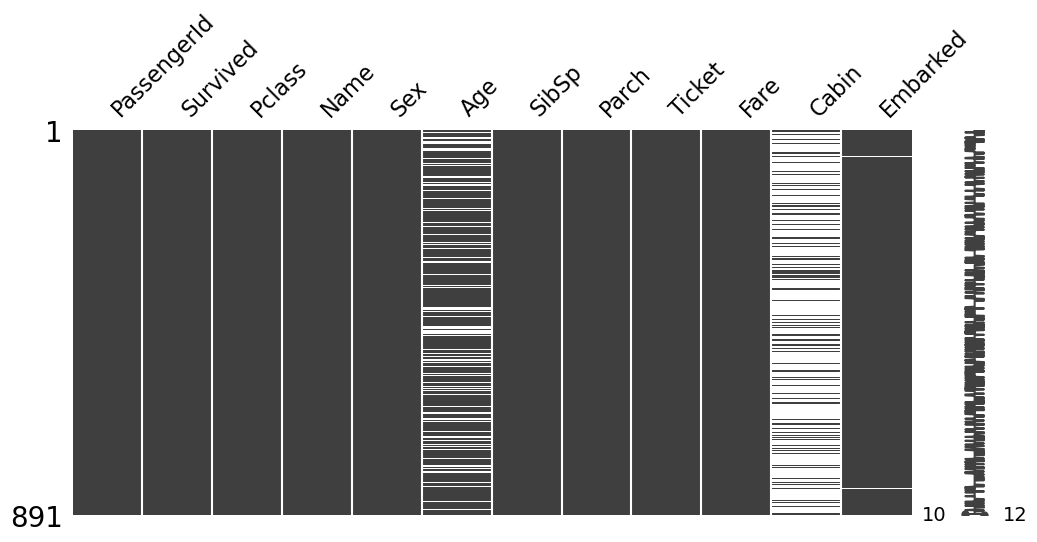

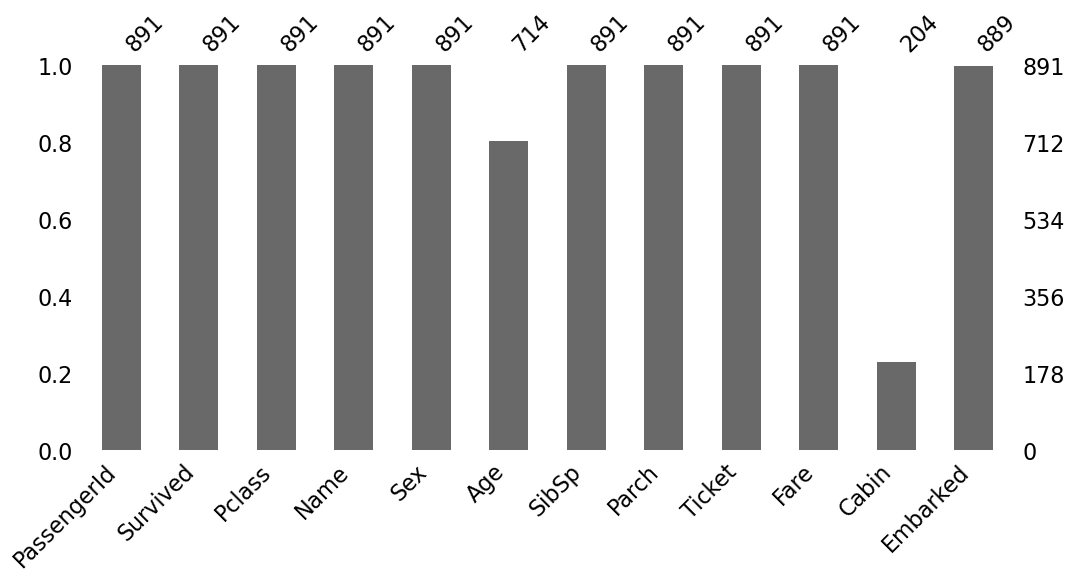

In [11]:
import missingno as msno
msno.matrix(df, figsize=(12,5))
plt.show()
msno.bar(df, figsize=(12,5))
plt.show()


Le graphique montre que 177 valeurs (20%) manquent pour l’âge, 687 (77%) pour la cabine et 2 (0,2%) pour le port d’embarquement. La cabine est trop lacunaire pour être utilisée en l’état, d’où le remplacement par "Unknown" et l’extraction du pont.

In [12]:
# Créer une copie propre
df_clean = df.copy()

# Appliquer les traitements sur df_clean
median_age = df_clean['Age'].median()
df_clean['Age'] = df_clean['Age'].fillna(median_age)
df_clean['Cabin'] = df_clean['Cabin'].fillna('Unknown')
df_clean = df_clean.dropna(subset=['Embarked'])


In [13]:
df_clean.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

 # Phase 5 : Identification des valeurs aberrantes 
Les valeurs aberrantes peuvent fausser les performances du modèle et influencer les relations entre les variables. Nous utiliserons des diagrammes en boîte pour identifier les valeurs aberrantes dans plusieurs colonnes numériques, notamment « âge », « tarif », « sibsp » et « parch ».

Pourquoi rechercher les valeurs aberrantes ?
Âge : Les valeurs extrêmes (par exemple, les passagers très jeunes ou très âgés) pourraient influencer les prévisions de survie.
Tarifs : Nous avons déjà constaté une asymétrie dans les données tarifaires, et les tarifs élevés pourraient représenter des individus fortunés ayant de meilleures chances de survie.

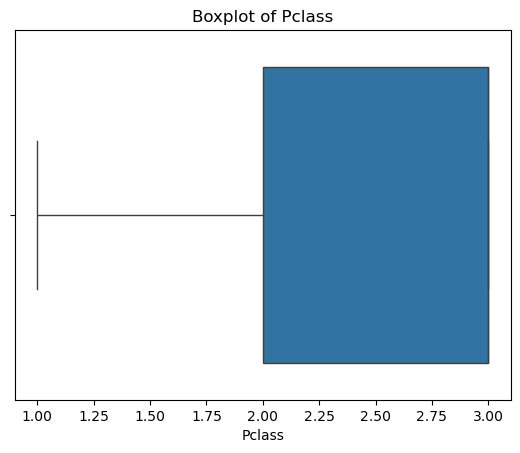

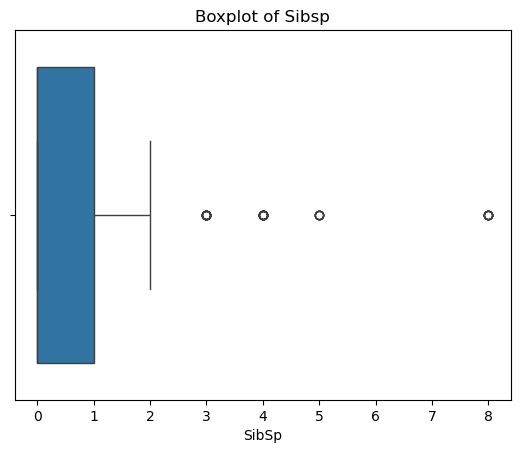

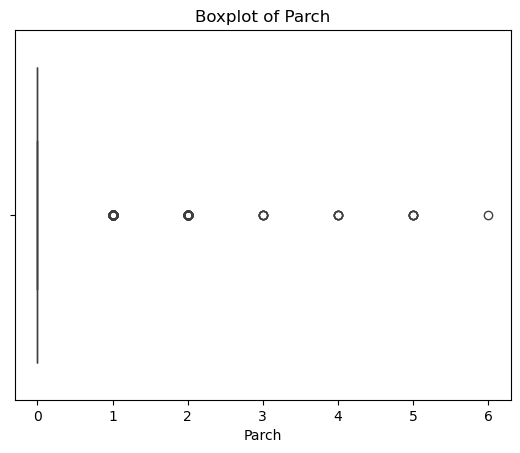

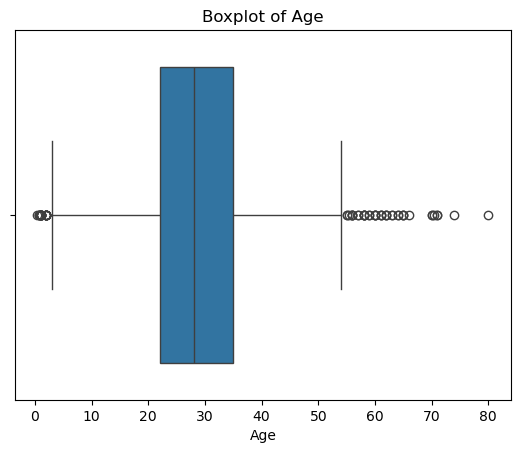

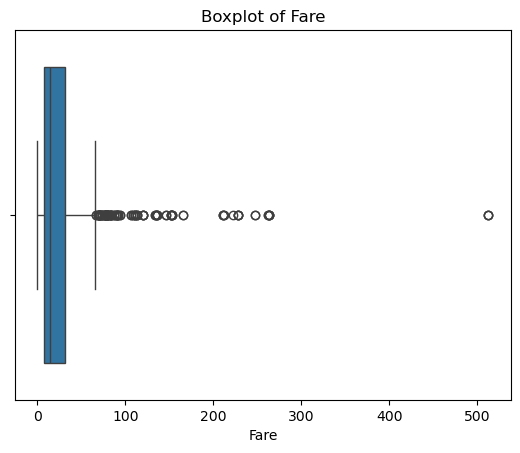

In [14]:
numerical_cols = ['Pclass','SibSp','Parch','Age', 'Fare']

for col in numerical_cols:
    sns.boxplot(x=df_clean[col])
    plt.title(f"Boxplot of {col.capitalize()}")
    plt.show()

In [15]:
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower) | (data[column] > upper)]
    return outliers

for col in ['Age', 'Fare']:
    out = detect_outliers_iqr(df_clean, col)
    print(f"{col}: {len(out)} outliers ({(len(out)/len(df_clean))*100:.1f}%)")

Age: 65 outliers (7.3%)
Fare: 114 outliers (12.8%)


Âge : La plupart des passagers se situent dans une fourchette raisonnable, mais on observe 65 valeurs extrêmes chez les passagers soit un taux de 7.3%. Ces cas aberrants pourraient nécessiter une attention particulière lors de la modélisation.
Tarif : Le diagramme en boîte confirme la présence de valeurs aberrantes, 114 passagers ont payé nettement plus que la majorité. Mais ces valeurs extrêmes observées sur l’âge (max 80 ans) et le tarif (max 512 USD) correspondent à des cas réels et plausibles. Aucune suppression n’a été appliquée, afin de ne pas biaiser la distribution naturelle des données

# Phase 6 : Exploration des corrélations

Nous examinerons les corrélations entre les variables numériques de notre jeu de données (âge, tarif, nombre de frères/époux, nombre de parents/enfants, etc.). Cela nous permettra de détecter d’éventuelles relations fortes entre certaines variables, susceptibles d’introduire de la multicolinéarité.
– Des corrélations proches de 1 ou de -1 indiquent une forte relation linéaire (positive ou négative) entre deux variables.
– Des corrélations proches de 0 indiquent une relation linéaire faible, voire inexistante.

## Encoder les données catégorielles sous forme numérique
L'encodage des variables catégorielles nous permettra de mesurer les corrélations entre les différents niveaux de ces variables et la survie. Ainsi, les variables catégorielles ont été encodées comme suit : Sex (male = 0, female = 1), Embarked (variables indicatrices avec suppression de la première modalité). La matrice de corrélation obtenue nous aide à explorer les relations linéaires entre ces variables et le statut de survie.

In [16]:
# Copie pour éviter de modifier l'original
df_corr = df_clean.copy()

# Encodage de Sex (binaire)
df_corr['Sex'] = df_corr['Sex'].map({'male': 0, 'female': 1})

# Encodage de Embarked (dummies) – on supprime la première colonne pour éviter colinéarité
embarked_dummies = pd.get_dummies(df_corr['Embarked'], prefix='Emb', drop_first=True)
df_corr = pd.concat([df_corr, embarked_dummies], axis=1)

# On peut aussi supprimer la colonne Embarked originale
df_corr.drop('PassengerId', axis=1, inplace=True)

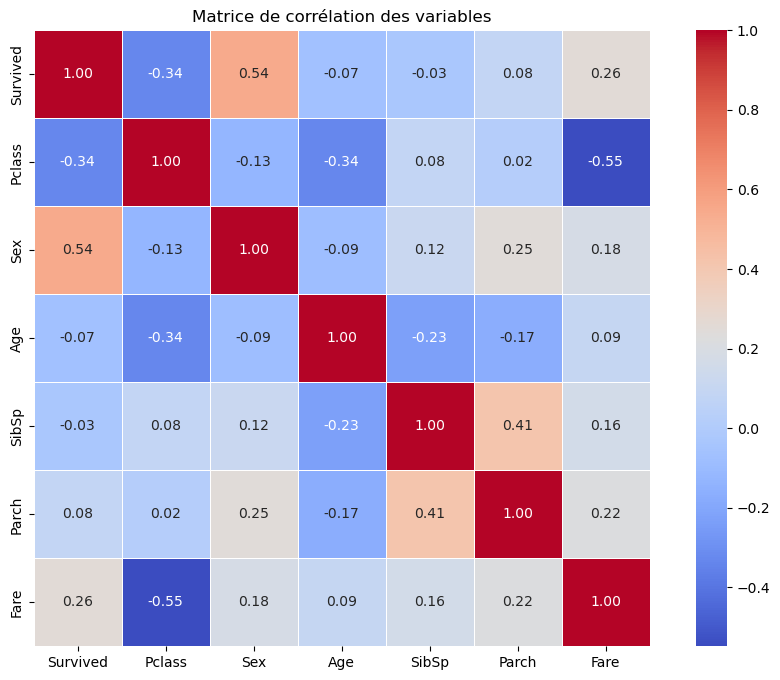

In [17]:
# Sélectionner uniquement les colonnes numériques (y compris les dummies)
colonnes_numeriques = df_corr.select_dtypes(include=['int64', 'float64']).columns
corr = df_corr[colonnes_numeriques].corr()

# Tracer la heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True, linewidths=0.5)
plt.title('Matrice de corrélation des variables')
plt.show()

In [18]:
print(corr['Survived'].sort_values(ascending=True))

Pclass     -0.335549
Age        -0.069822
SibSp      -0.034040
Parch       0.083151
Fare        0.255290
Sex         0.541585
Survived    1.000000
Name: Survived, dtype: float64


 ## Interprétation rapide des corrélations avec Survived
Les principales corrélations observées :

Survived est fortement corrélé avec Sex (0,54) : les femmes survivent plus.

Corrélation négative avec Pclass (-0,34) : les classes inférieures survivent moins.

Corrélation positive avec Fare (0,26) : les tarifs élevés sont associés à la survie.

Age, SibSp, Parch ont des corrélations faibles.

# Phase 7 : les Diagrammes

Les diagrammes permettent d'avoir un visuel sur les variables

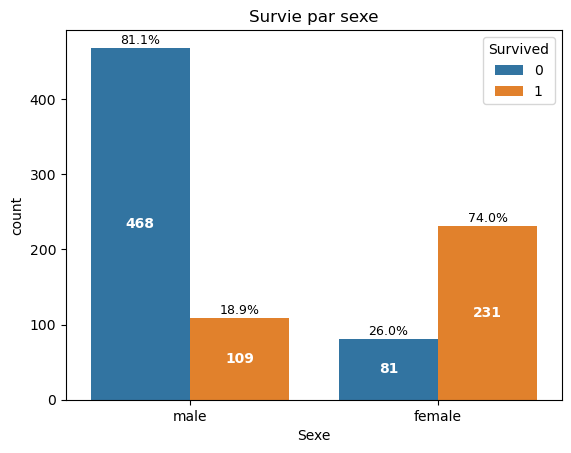

In [19]:
# Sex
fig, ax = plt.subplots()
sns.countplot(data=df_clean, x='Sex', hue='Survived', ax=ax)
ax.set_title('Survie par sexe')

totals = df_clean.groupby('Sex').size()
cats = [tick.get_text() for tick in ax.get_xticklabels()]

for bar in ax.patches:
    h = bar.get_height()
    if h > 0:
        x_center = bar.get_x() + bar.get_width()/2
        idx = np.argmin(np.abs(ax.get_xticks() - x_center))
        cat = cats[idx]
        total = totals[cat]
        pct = h / total * 100
        ax.text(bar.get_x()+bar.get_width()/2, h/2, f'{int(h)}',
                ha='center', va='center', color='white', fontweight='bold')
        ax.text(bar.get_x()+bar.get_width()/2, h+1, f'{pct:.1f}%',
                ha='center', va='bottom', fontsize=9)
plt.xlabel('Sexe')        
plt.show()

Interprétation :

Femmes : ~74% survivantes, ~26% décédées.

Hommes : ~19% survivants, ~81% décédés.

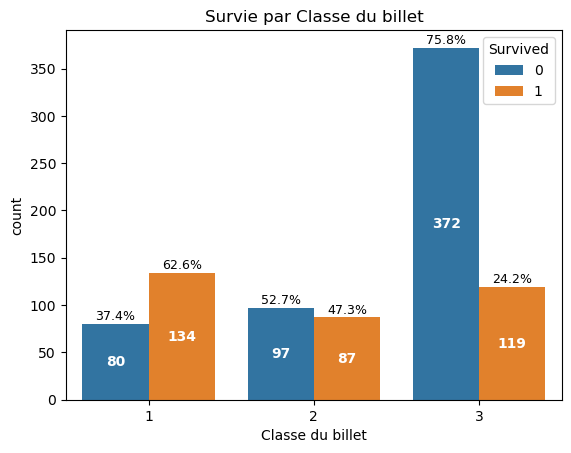

In [20]:

# Créer le graphique
ax = sns.countplot(data=df_clean, x='Pclass', hue='Survived')
plt.title('Survie par Classe du billet')

# Calculer les effectifs totaux par classe
totals = df_clean.groupby('Pclass').size()  # index = 1,2,3

# Récupérer les positions et libellés des classes sur l'axe x
ticks = ax.get_xticks()
class_labels = [int(label.get_text()) for label in ax.get_xticklabels()]

# Parcourir toutes les barres
for bar in ax.patches:
    height = bar.get_height()
    if height > 0:
        # Trouver la classe correspondant à la position x de la barre
        x_center = bar.get_x() + bar.get_width() / 2
        idx = np.argmin(np.abs(ticks - x_center))
        pclass = class_labels[idx]
        total = totals[pclass]
        pct = (height / total) * 100

        # Effectif à l'intérieur de la barre
        ax.text(bar.get_x() + bar.get_width()/2, height/2, f'{int(height)}',
                ha='center', va='center', color='white', fontweight='bold')
        # Pourcentage au-dessus de la barre
        ax.text(bar.get_x() + bar.get_width()/2, height + 1, f'{pct:.1f}%',
                ha='center', va='bottom', fontsize=9)
plt.xlabel('Classe du billet') 
plt.show()

Interprétation :

Classe 1 : 63% de survie.

Classe 2 : 47% de survie.

Classe 3 : 24% de survie.

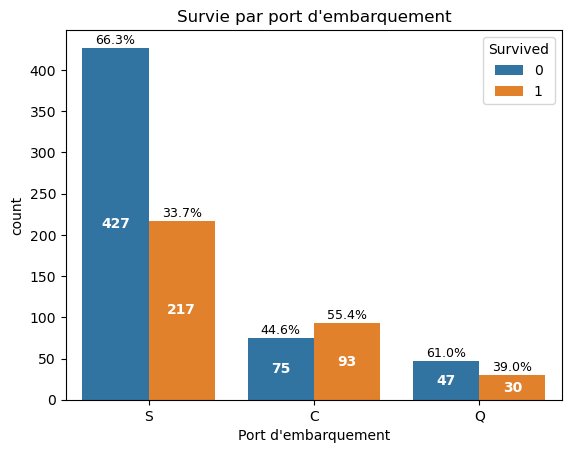

In [21]:
# Embarked
fig, ax = plt.subplots()
sns.countplot(data=df_clean, x='Embarked', hue='Survived', ax=ax)
ax.set_title('Survie par port d\'embarquement')

totals = df_clean.groupby('Embarked').size()
cats = [tick.get_text() for tick in ax.get_xticklabels()]

for bar in ax.patches:
    h = bar.get_height()
    if h > 0:
        x_center = bar.get_x() + bar.get_width()/2
        idx = np.argmin(np.abs(ax.get_xticks() - x_center))
        cat = cats[idx]
        total = totals[cat]
        pct = h / total * 100
        ax.text(bar.get_x()+bar.get_width()/2, h/2, f'{int(h)}',
                ha='center', va='center', color='white', fontweight='bold')
        ax.text(bar.get_x()+bar.get_width()/2, h+1, f'{pct:.1f}%',
                ha='center', va='bottom', fontsize=9)
plt.xlabel('Port d\'embarquement')        
plt.show()

Interpétation :

Cherbourg (C) présente le meilleur taux de survie (~55 %), suivi de Queenstown (Q) avec ~39 % et Southampton (S) avec le taux le plus faible (~34 %). Cette différence s’explique par la sur‑représentation des passagers de première classe à Cherbourg et de troisième classe à Southampton.


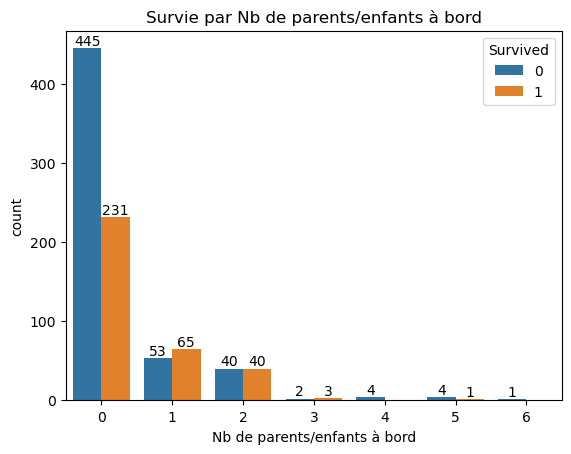

In [22]:
# Créer le graphique
ax = sns.countplot(data=df_clean, x='Parch', hue='Survived')
plt.title('Survie par Nb de parents/enfants à bord')

# Ajouter les effectifs sur les barres
for container in ax.containers:
    ax.bar_label(container, label_type='edge', fmt='%d')
plt.xlabel('Nb de parents/enfants à bord')
plt.show()

Les passagers accompagnés d’un ou deux proches avaient une chance plus élevée de survivre, tandis que les passagers seuls ou issus de grandes familles étaient plus vulnérables.

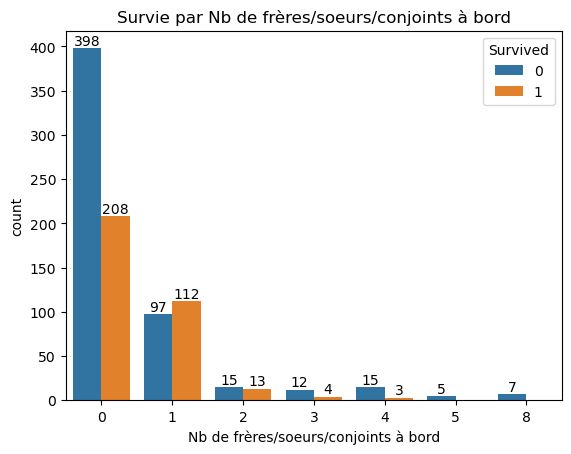

In [23]:
# Créer le graphique
ax = sns.countplot(data=df_clean, x='SibSp', hue='Survived')
plt.title('Survie par Nb de frères/soeurs/conjoints à bord')

# Ajouter les effectifs sur les barres
for container in ax.containers:
    ax.bar_label(container, label_type='edge', fmt='%d')

plt.xlabel('Nb de frères/soeurs/conjoints à bord')
plt.show()

Les passagers seuls ou issus de grandes familles avaient une chance plus faible de survivre, tandis que ceux accompagnés d’un seul proche bénéficiaient d’un avantage net.

In [24]:
df_clean['Deck'] = df_clean['Cabin'].str[0]  # première lettre
deck_survival = df_clean.groupby('Deck')['Survived'].agg(['count', 'mean']).rename(columns={'mean': 'survival_rate'})
deck_survival['survival_rate'] = (deck_survival['survival_rate'] * 100).round(1)
print(deck_survival.sort_values('survival_rate', ascending=False))

      count  survival_rate
Deck                      
D        33           75.8
E        32           75.0
B        45           73.3
F        13           61.5
C        59           59.3
G         4           50.0
A        15           46.7
U       687           30.0
T         1            0.0


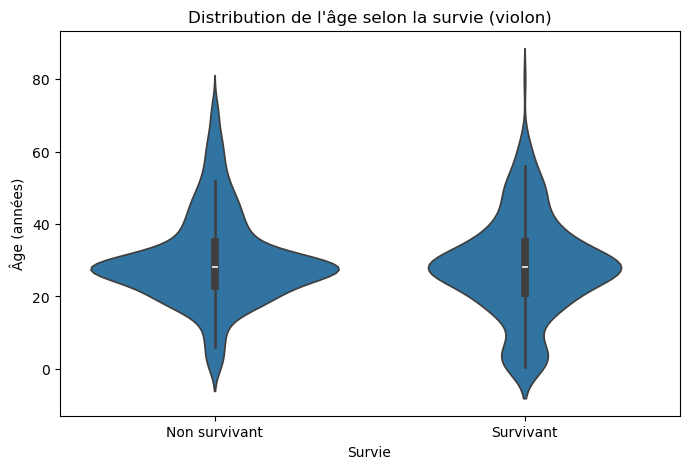

In [25]:
plt.figure(figsize=(8,5))
sns.violinplot(data=df_clean, x='Survived', y='Age')
plt.title('Distribution de l\'âge selon la survie (violon)')
plt.xticks([0,1], ['Non survivant', 'Survivant'])
plt.xlabel('Survie')
plt.ylabel('Âge (années)')
plt.show()

Les enfants de moins de 10 ans bénéficient clairement de la règle « les femmes et les enfants d’abord » (61 % de survie). En revanche, les jeunes adultes (21‑30 ans) présentent le taux de survie le plus faible (32,5 %). On observe une remontée pour la tranche 31‑40 ans (43,4 %), puis une chute chez les plus de 60 ans (24 %).

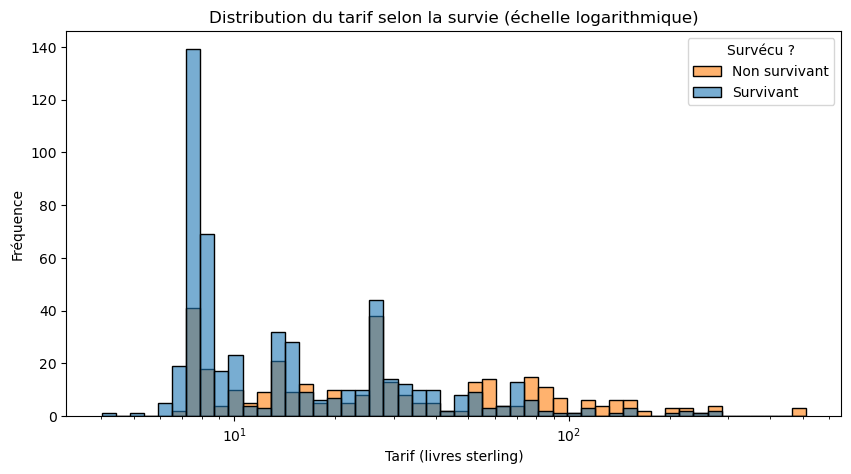

In [26]:
plt.figure(figsize=(10,5))
sns.histplot(data=df_clean, x='Fare', hue='Survived', bins=50, log_scale=True, alpha=0.6)
plt.title('Distribution du tarif selon la survie (échelle logarithmique)')
plt.xlabel('Tarif (livres sterling)')
plt.ylabel('Fréquence')
plt.legend(title='Survécu ?', labels=['Non survivant', 'Survivant'])
plt.show()

Les survivants ont des tarifs généralement plus élevés.

La distribution est très asymétrique.

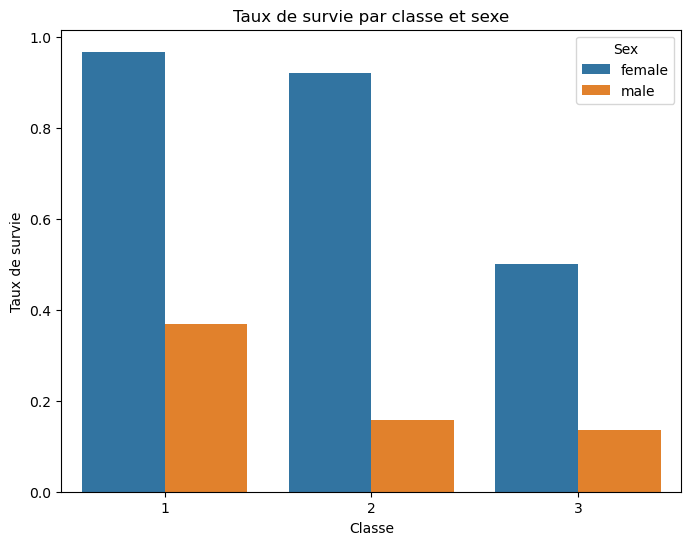

Survived          0     1
Sex    Pclass            
female 1        3.3  96.7
       2        7.9  92.1
       3       50.0  50.0
male   1       63.1  36.9
       2       84.3  15.7
       3       86.5  13.5


In [27]:
plt.figure(figsize=(8,6))
sns.barplot(data=df_clean, x='Pclass', y='Survived', hue='Sex', errorbar=None)
plt.title('Taux de survie par classe et sexe')
plt.xlabel('Classe')
plt.ylabel('Taux de survie')
plt.show()

# Tableau croisé
cross_sex_class = pd.crosstab([df_clean['Sex'], df_clean['Pclass']], df_clean['Survived'], normalize='index') * 100
print(cross_sex_class.round(1))

Les femmes de première classe ont survécu à 97%, contre seulement 13% des hommes de troisième classe.
L’effet de la classe est très marqué chez les femmes, mais reste présent chez les hommes (hommes 1ʳᵉ classe : ~37%, 3ᵉ classe : ~13%).

In [28]:
from scipy.stats import chi2_contingency

def chi2_test(var):
    contingency = pd.crosstab(df_clean[var], df_clean['Survived'])
    chi2, p, dof, ex = chi2_contingency(contingency)
    return p

for var in ['Sex', 'Pclass', 'Embarked']:
    p = chi2_test(var)
    print(f"{var}: p-value = {p:.4f} → significatif si p < 0.05")

Sex: p-value = 0.0000 → significatif si p < 0.05
Pclass: p-value = 0.0000 → significatif si p < 0.05
Embarked: p-value = 0.0000 → significatif si p < 0.05


Toutes les variables catégorielles testées sont statistiquement liées à la survie (p < 0.001).

# Phase 8 : Conclusion de l'analyse exploratoire

Cette analyse exploratoire confirme trois facteurs déterminants de la survie : le sexe (les femmes survivent 4 fois plus que les hommes), la classe sociale (la première classe offre 2,6 fois plus de chances que la troisième) et la taille de la famille (un à deux proches est optimal).
L’âge a un impact plus nuancé : seuls les enfants de moins de 10 ans bénéficient clairement de la règle de priorité.
Le port d’embarquement agit comme un proxy de la répartition des classes sociales.
Limites : Cette EDA ne mesure pas les interactions complexes (ex. femmes de première classe vs hommes de troisième) ni l’effet des variables continues après transformation. Une modélisation prédictive (régression logistique, random forest) permettrait de quantifier l’importance relative de chaque facteur et de détecter d’éventuelles non‑linéarités.